In [1]:
from keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000
)

I0000 00:00:1785092986.104566    8104 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785092986.762635    8104 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785092988.643820    8104 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Multiclass (Single-Label) Classification: Reuters Newswire Topics

**Task:** classify each short newswire into exactly one of **46 mutually exclusive topics** (e.g., "earnings," "acquisitions," "grain," ...). This is a step up from [binary classification](./binary_classification.ipynb): instead of one probability answering a yes/no question, the model now has to output a probability *distribution over 46 classes* and pick the most likely one.

This is specifically **single-label, multiclass** classification — each newswire has exactly one correct topic (unlike *multi-label* classification, where an example could belong to several classes at once, e.g., tagging an article as both "earnings" and "acquisitions"). That distinction drives essentially every design choice below: how labels get encoded, which activation the output layer uses, and which loss function trains it.

**Dataset:** the Reuters dataset, built into Keras — 11,228 short newswires, pre-tokenized into sequences of word indices (same format as the IMDB dataset), each tagged with one of 46 topic labels. The classes are **not balanced** — some topics (like "earnings") have hundreds of examples, others have only a handful — which matters when interpreting accuracy later.

**What's new compared to binary classification:** everywhere the binary model had "1 output, sigmoid, binary_crossentropy," this model needs "46 outputs, softmax, categorical_crossentropy." The notebook below walks through why.

In [2]:
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join(
    # The indices are offset by 3 because 0, 1, and 2 are reserved
    # indices for "padding," "start of sequence," and "unknown."
    [reverse_word_index.get(i - 3, "?") for i in train_data[10]]
)

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Same idea as the IMDB decoding step: `train_data[10]` is a list of integer word indices, and this just reverses `word_index` to render it back as readable text — a sanity check, not something the model uses.

In [3]:
train_labels[10]

np.int64(3)

`train_labels[10]` is `3` — a raw integer topic ID between 0 and 45, not a name like "earnings." This is the label format Keras hands us: one integer per example, indicating which of the 46 classes it belongs to. As we'll see below, this integer format isn't what we ultimately train on — it needs to be transformed first.

In [9]:
import numpy as np
def multi_hot_encode(sequences, num_classes):
    # Creates an all-zero matrix of shape (len(sequences), num_classes)
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        # Sets specific indices of results[i] to 1s
        results[i][sequence] = 1.0
    return results

## Vectorizing the input text (same trick as binary classification)

`Dense` layers need fixed-size numeric input, but each newswire is a variable-length list of word indices. `multi_hot_encode` solves this the same way as in the IMDB notebook: it builds a 10,000-dimensional "bag of words" vector per example, 1 at every index of a word that appears in the text, 0 elsewhere. This throws away word order and word count, keeping only *which* words showed up — crude, but a solid baseline for topic classification, where individual keywords ("oil," "shares," "wheat") are often strongly predictive of the topic on their own.

In [10]:
# Vectorized training data
x_train = multi_hot_encode(train_data, num_classes=10000)
# Vectorized test data
x_test = multi_hot_encode(test_data, num_classes=10000)

## Encoding the labels: why not just feed in the integer `3`?

This is the real conceptual difference from binary classification. In the binary case, the label was already a meaningful number (`0` or `1`) directly comparable to a `sigmoid` probability. Here, the label `3` is just an arbitrary **category ID** — topic 3 isn't "more" than topic 2 in any numeric sense, they're just different buckets. If we trained the network to regress toward the raw integer, it would wrongly learn that topic 45 is "further" from topic 0 than topic 1 is, imposing a false ordinal relationship on unordered categories.

The fix is **one-hot encoding**: represent each label as a 46-dimensional vector that's all zeros except for a single 1 at the position of the correct class. Label `3` becomes `[0, 0, 0, 1, 0, 0, ..., 0]`. This is the label-side counterpart to the softmax output layer below — the network is trained to make its 46-way probability distribution match this "certain, all-or-nothing" one-hot distribution as closely as possible.

In [12]:
def one_hot_encode(labels, num_classes=46):
    results = np.zeros((len(labels), num_classes))
    for i, label in enumerate(labels):
        results[i, label] = 1.0
    return results

In [13]:
# Vectorized training labels
y_train = one_hot_encode(train_labels)
# Vectorized test labels
y_test = one_hot_encode(test_labels)

`y_train` now has shape `(8982, 46)` — one 46-length one-hot row per example — printed in the next cell.

In [14]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(8982, 46))

### `to_categorical`: the built-in version of what we just wrote by hand

The next cell overwrites `y_train`/`y_test` using `keras.utils.to_categorical`, which does exactly what the hand-rolled `one_hot_encode` above does — this notebook implements it manually first (as a teaching exercise, mirroring how `multi_hot_encode` was written from scratch too) and then swaps in the library version, which is what you'd actually use in practice. The output is identical to what's printed above.

In [20]:
import keras
from keras import layers
from keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

## Building the network: wider hidden layers, `softmax` output

```python
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax"),
])
```

**Why 64 units instead of the 16 used for binary IMDB classification?**
This comes back to the **information bottleneck** idea from the binary notebook: each hidden layer is an intermediate representation the network must squeeze the input through, and it must retain enough information to make the *final* prediction. The final layer here has to distinguish between **46** classes, versus just 1 probability for binary classification. If an intermediate layer were narrower than 46 (say, 16 or 32 units), it would be forced to compress information into fewer dimensions than there are output classes — provably discarding information that later layers can never recover, which tends to show up as a hard ceiling on accuracy no matter how long you train. 64 gives the network comfortable headroom above the 46-class output.

**Why `softmax` instead of `sigmoid`, and 46 output units instead of 1?**
`sigmoid` treats each output unit as an *independent* yes/no probability — appropriate when classes aren't mutually exclusive. Here they are: a newswire is about exactly one topic, so the 46 output probabilities should behave like a single probability distribution — non-negative and **summing to 1**. `softmax(x)_i = exp(x_i) / sum_j(exp(x_j))` guarantees exactly that: every output is in `(0, 1)`, and they all add up to 1, so they can be read directly as "the model's belief that this is topic `i`, given that it's certain the true topic is one of the 46." The predicted class is simply `argmax` of that vector.

In [21]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)

## Compiling: `categorical_crossentropy` and a top-3 accuracy metric

```python
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy", top_3_accuracy])
```

**`categorical_crossentropy`** is the multiclass generalization of the `binary_crossentropy` used for IMDB. For one example with one-hot true label `y` and predicted probability vector `p` (both length 46):

`loss = -sum_i( y_i · log(p_i) )`

Since `y` is one-hot, only one term in that sum survives — the log-probability the model assigned to the *correct* class. So this loss is just `-log(p_correct)`: it penalizes the model exactly in proportion to how much probability mass it failed to put on the right answer, regardless of how that model distributed the remaining probability across the 45 wrong classes. `categorical_crossentropy` requires one-hot labels (matching `to_categorical` above); if you instead kept labels as plain integers, you'd use `sparse_categorical_crossentropy`, which computes the same mathematical loss but reads `y` as a class index instead of a one-hot vector.

**`top_3_accuracy`** (`TopKCategoricalAccuracy(k=3)`) counts a prediction correct if the true class is anywhere in the model's top-3 highest-probability guesses, not just its single top pick. This is a useful secondary metric here specifically because the 46 topics are imbalanced and some are semantically close (e.g., "grain" vs. "wheat" vs. "corn") — a model can be "nearly right" in a way plain accuracy doesn't reward, and top-3 accuracy quantifies that.

In [22]:
top_3_accuracy = keras.metrics.TopKCategoricalAccuracy(
    k=3, name="top_3_accuracy"
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy", top_3_accuracy],
)

W0000 00:00:1785093344.281916    8326 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1785093344.596734    8104 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Held-out validation set

Same purpose as in the binary classification notebook: 1,000 examples are set aside from the training data (never touched during weight updates) so we can watch for the gap between training and validation performance that signals overfitting. Note the split here is only 1,000 out of 8,982 examples (~11%) rather than the 10,000-out-of-25,000 (~40%) used for IMDB — with fewer total examples and 46 classes to represent, holding back a smaller fraction leaves more data for the model to actually learn from, at the cost of a noisier validation estimate.

In [23]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

## Training

Same mechanics as before — mini-batches of `batch_size=512` examples, `epochs=20` full passes over `partial_x_train`, with `validation_data=(x_val, y_val)` checked after every epoch. Unlike the binary classification notebook, `fit()` is only called once here on a freshly-built model, so these 20 epochs are a single clean run (no weight-carryover gotcha to watch for).

Looking at the recorded training log: training accuracy climbs to ~96% while validation accuracy plateaus around ~82% and validation loss (`val_loss`) starts creeping back up after roughly epoch 9-10 even as training loss keeps dropping — the same overfitting signature seen with IMDB, just measured across 46 classes instead of 2.

In [24]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4187 - loss: 3.3938 - top_3_accuracy: 0.5496 - val_accuracy: 0.5530 - val_loss: 2.7098 - val_top_3_accuracy: 0.7010
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6243 - loss: 2.1182 - top_3_accuracy: 0.7507 - val_accuracy: 0.6580 - val_loss: 1.7456 - val_top_3_accuracy: 0.7600
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7117 - loss: 1.3969 - top_3_accuracy: 0.8011 - val_accuracy: 0.7160 - val_loss: 1.3333 - val_top_3_accuracy: 0.8210
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7711 - loss: 1.0581 - top_3_accuracy: 0.8637 - val_accuracy: 0.7470 - val_loss: 1.1637 - val_top_3_accuracy: 0.8500
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8232 - loss: 0.8324 - top_3_accuracy: 0.9059 - val_accuracy: 0.7740 - val_loss: 1.0507 - val_top_3_accuracy: 0.8790
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8681 - loss: 0.6491 - top_3_ac

## Plotting the training curves

Same diagnostic as before: training loss falling monotonically while validation loss bottoms out and then rises marks the overfitting point. *(Note: the original version of this cell was missing `import matplotlib.pyplot as plt` and would raise `NameError: name 'plt' is not defined` — that import has been added.)*

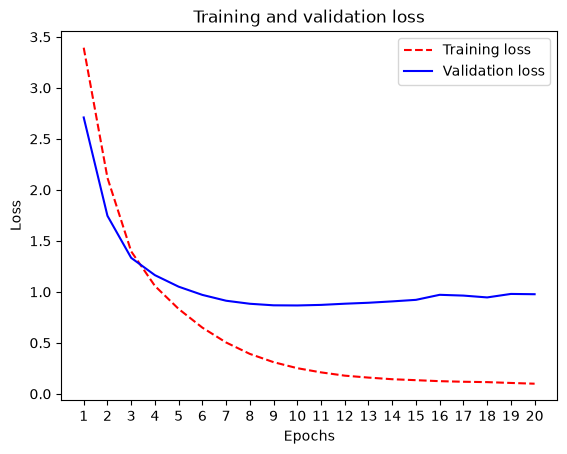

In [28]:
import matplotlib.pyplot as plt

loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

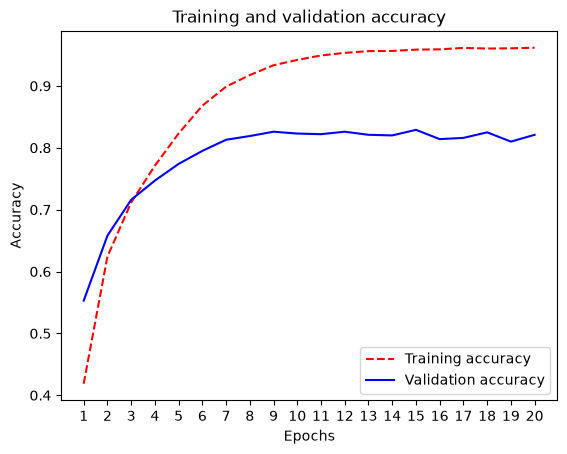

In [29]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Plain (top-1) accuracy: the fraction of newswires where the model's single highest-probability guess (`argmax` of the softmax output) exactly matches the true topic.

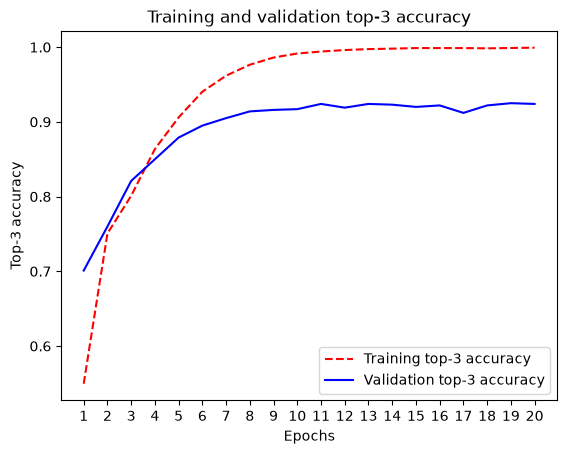

In [30]:
plt.clf()
acc = history.history["top_3_accuracy"]
val_acc = history.history["val_top_3_accuracy"]
plt.plot(epochs, acc, "r--", label="Training top-3 accuracy")
plt.plot(epochs, val_acc, "b", label="Validation top-3 accuracy")
plt.title("Training and validation top-3 accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Top-3 accuracy")
plt.legend()
plt.show()

Top-3 accuracy: the fraction of newswires where the true topic is among the model's 3 highest-probability guesses. Comparing this curve to top-1 accuracy above shows how much of the model's "errors" are actually near-misses — cases where the correct topic was ranked 2nd or 3rd — versus the model being genuinely far off.

## Takeaways

- Single-label multiclass classification pairs **one-hot labels + `softmax` output + `categorical_crossentropy` loss**, the direct generalization of binary classification's **scalar labels + `sigmoid` + `binary_crossentropy`**.
- Hidden layer width should stay comfortably above the number of output classes to avoid an information bottleneck that caps achievable accuracy.
- The same overfitting pattern (training metrics keep improving, validation metrics plateau then regress) shows up regardless of how many classes there are — the standard remedies (fewer epochs, `Dropout`, weight regularization, more training data) apply here just as they did for IMDB.